# BERT vs. GPT: Encoder-Only vs. Decoder-Only

### Dos arquitecturas, el mismo mecanismo de atencion

Con BERT: le pasamos una oracion completa, y cada token podia "mirar" a todos los demas tokens (para atras y para adelante) para construir su representacion. Eso es lo que se llama un modelo **encoder-only**, y es lo que hace a BERT tan bueno para tareas de comprension, como la clasificacion de sentimiento que entrenamos.

GPT es la otra gran familia de modelos basados en Transformers, y es un modelo **decoder-only**. Usa el mismo mecanismo de self-attention que ya conocemos, pero con una restriccion clave: cada token solo puede mirar a los tokens que vinieron *antes* que el, nunca a los que vienen despues. Esa sola diferencia cambia para que sirve mejor cada arquitectura, y como se las adapta a una tarea nueva.

El objetivo de este notebook es entender, de forma visual y practica, en que se parecen y en que se diferencian estos dos modelos.

### El plan de hoy

1. Cargar BERT (encoder) y GPT-2 (decoder), y tokenizar la misma oracion con los dos.
2. Visualizar la atencion de cada uno, lado a lado, para ver la diferencia entre atencion bidireccional y atencion causal.
3. Entender por que BERT usa el token `[CLS]` para resumir una oracion, y por que GPT no tiene un equivalente al principio de la secuencia.
4. Ver, con un ejemplo minimo, la otra forma de usar un modelo tipo GPT para una tarea: no entrenandolo, sino escribiendole un prompt.
5. Cerrar con una comparacion directa de las dos arquitecturas.

## 0. Preparando el entorno

In [1]:
!pip install transformers matplotlib

In [2]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

## 1. Cargando los dos modelos

Para BERT, seguimos usando `bert-base-multilingual-cased`, el mismo modelo con el que trabajamos todo el modulo. Para GPT, usamos `gpt2`: el modelo original de OpenAI, chico (124 millones de parametros) y en ingles, pensado para generar texto en vez de clasificarlo.

A los dos les pedimos `output_attentions=True`, igual que en el notebook de exploracion de BERT, para poder ver por dentro.

In [3]:
# =========================
# BERT: Encoder-Only
# =========================

# Nombre del modelo BERT multilingüe preentrenado.
nombre_bert = "bert-base-multilingual-cased"

# Carga el tokenizador para convertir texto en tokens/IDs que BERT pueda entender.
tokenizer_bert = AutoTokenizer.from_pretrained(nombre_bert)

# Carga BERT y activa la salida de las matrices de atención.
modelo_bert = AutoModel.from_pretrained(nombre_bert, output_attentions=True)

# Pone el modelo en modo evaluación (no entrenamiento).
modelo_bert.eval()



config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [4]:
# =========================
# GPT-2: Decoder-Only
# =========================

# Nombre del modelo GPT-2 preentrenado (small, openly available Transformer model from HuggingFace)
nombre_gpt = "gpt2"

# Carga el tokenizador de GPT-2.
tokenizer_gpt = AutoTokenizer.from_pretrained(nombre_gpt)

# Carga GPT-2 como modelo causal para predecir el siguiente token. También pedimos que devuelva las matrices de atención.
modelo_gpt = AutoModelForCausalLM.from_pretrained(nombre_gpt, output_attentions=True)

# Pone el modelo en modo evaluación.
modelo_gpt.eval()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [5]:
# Muestra cuántas capas Transformer y cabezas de atención tiene BERT.
print("Capas BERT:", modelo_bert.config.num_hidden_layers, "- Cabezas por capa:", modelo_bert.config.num_attention_heads)

# Muestra las capas y cabezas de atención de GPT-2.
print("Capas GPT-2:", modelo_gpt.config.n_layer, "- Cabezas por capa:", modelo_gpt.config.n_head)

Capas BERT: 12 - Cabezas por capa: 12
Capas GPT-2: 12 - Cabezas por capa: 12


## 2. La misma oracion, dos tokenizadores distintos

Usamos la misma oracion de ejemplo del notebook de exploracion de BERT. BERT la tokeniza con WordPiece; GPT-2 usa BPE (el mismo algoritmo que programamos a mano hace unas semanas). Comparemos los resultados.

In [9]:
oracion_ejemplo = "The flight was cancelled and nobody explained why."

# Generar los tensores de PyTorch con el tokenizador de BERT
encoding_bert = tokenizer_bert(oracion_ejemplo, return_tensors="pt")
# Convertir los IDs de tokens a cadenas de texto
tokens_bert = tokenizer_bert.convert_ids_to_tokens(encoding_bert["input_ids"][0])

# Generar los tensores de PyTorch con el tokenizador de GPT-2
encoding_gpt = tokenizer_gpt(oracion_ejemplo, return_tensors="pt")
# Convertir los IDs de tokens a cadenas de texto
tokens_gpt = tokenizer_gpt.convert_ids_to_tokens(encoding_gpt["input_ids"][0])

print("Tokens BERT (WordPiece):", tokens_bert)
print("Tokens GPT-2 (BPE):     ", tokens_gpt)

Tokens BERT (WordPiece): ['[CLS]', 'The', 'flight', 'was', 'cancelled', 'and', 'no', '##body', 'explained', 'why', '.', '[SEP]']
Tokens GPT-2 (BPE):      ['The', 'Ġflight', 'Ġwas', 'Ġcancelled', 'Ġand', 'Ġnobody', 'Ġexplained', 'Ġwhy', '.']


Un par de detalles para fijarse:

- BERT agrega `[CLS]` al principio y `[SEP]` al final. GPT-2 no agrega ningun token especial: la secuencia empieza directamente con el primer token de la oracion.
- Hay el caracter `Ġ` al principio de algunos tokens de GPT-2. Es la forma que tiene el tokenizador de BPE de GPT-2 de marcar "este token empieza con un espacio antes". No es un error ni un caracter raro del idioma, es parte de como BPE representa los espacios.

## 3. La diferencia clave: que puede "ver" cada token

Extraigamos la matriz de atencion de una capa de cada modelo, promediando entre las distintas cabezas, y grafiquemoslas una al lado de la otra.

In [8]:
# Desactivamos el cálculo de gradientes
with torch.no_grad():
    salida_bert = modelo_bert(**encoding_bert) # Pasamos los tokens de entrada por BERT. (** --> para unpack el dictionario)
    salida_gpt = modelo_gpt(**encoding_gpt) # Pasamos los tokens de entrada por GPT-2.

capa = -1  # la ultima capa de cada modelo

# Obtenemos la atención de la última capa de BERT.
# mean(dim=1) = hacemos el promedio de todas las cabezas de atención.
# [0] = seleccionamos el primer ejemplo del batch.
# .numpy() = convertimos el tensor de PyTorch a un array de NumPy.
matriz_bert = salida_bert.attentions[capa].mean(dim=1)[0].numpy()

# Hacemos lo mismo para GPT-2.
matriz_gpt = salida_gpt.attentions[capa].mean(dim=1)[0].numpy()

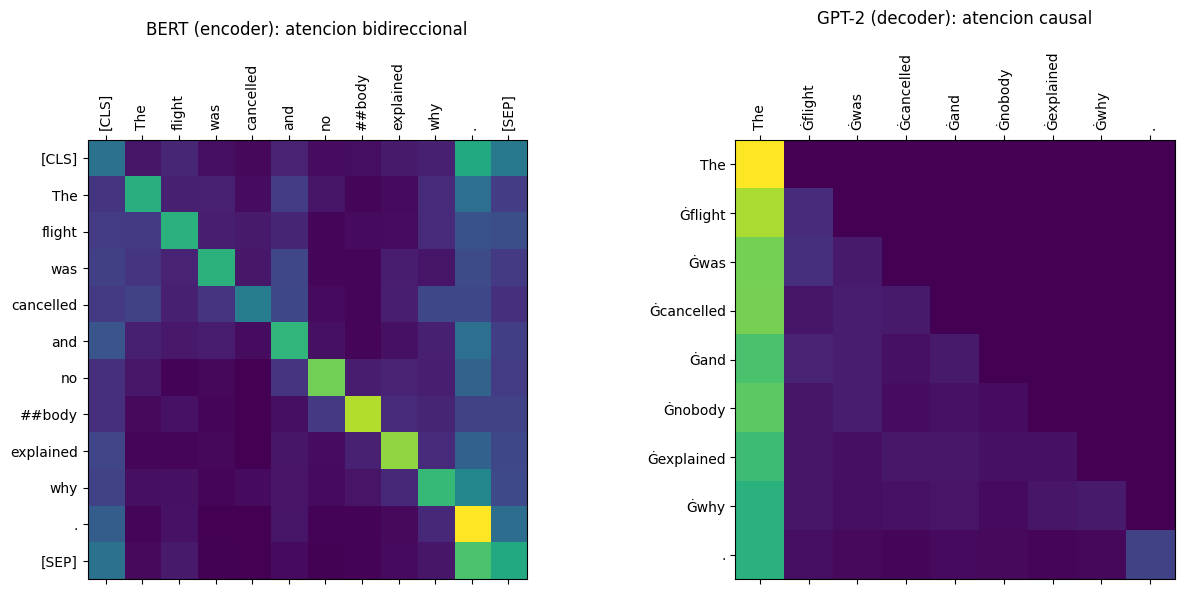

In [10]:
def graficar_comparacion(matriz_izq, tokens_izq, titulo_izq, matriz_der, tokens_der, titulo_der):
    figura, (eje_izq, eje_der) = plt.subplots(1, 2, figsize=(13, 6))

    for eje, matriz, tokens, titulo in [
        (eje_izq, matriz_izq, tokens_izq, titulo_izq),
        (eje_der, matriz_der, tokens_der, titulo_der),
    ]:
        mapa = eje.matshow(matriz, cmap="viridis")
        eje.set_xticks(range(len(tokens)))
        eje.set_yticks(range(len(tokens)))
        eje.set_xticklabels(tokens, rotation=90)
        eje.set_yticklabels(tokens)
        eje.set_title(titulo, pad=20)

    plt.tight_layout()
    plt.show()


graficar_comparacion(
    matriz_bert, tokens_bert, "BERT (encoder): atencion bidireccional",
    matriz_gpt, tokens_gpt, "GPT-2 (decoder): atencion causal",
)

Fijate en la mitad superior derecha de cada mapa de calor (arriba de la diagonal):

- En el mapa de **BERT**, hay valores en toda la matriz: cualquier token le puede prestar atencion a cualquier otro, este antes o despues en la oracion.
- En el mapa de **GPT-2**, por grand parte es practicamente en negro (valores en cero, o muy cercanos). Eso no se espera: GPT-2 aplica una **mascara causal** que le prohibe a cada token mirar tokens futuros. El token en la posicion `i` solo puede prestarle atencion a los tokens en las posiciones `0` a `i`.

Esta mascara es la diferencia arquitectonica central entre un encoder y un decoder. Todo lo demas (self-attention, capas apiladas, conexiones residuales) es esencialmente el mismo mecanismo que ya conocemos de BERT.

## 4. Por que BERT tiene `[CLS]` y GPT no tiene un equivalente

En el notebook de exploracion de BERT usamos el vector del token `[CLS]` como resumen de toda la oracion, porque gracias a la atencion bidireccional, `[CLS]` ya "vio" todos los demas tokens.

En GPT-2 no existe un token asi. Por la mascara causal, el *unico* token que llega a ver la oracion completa es el **ultimo**, porque es el unico que tiene a todos los demas tokens antes que el. Comprobemos esto mirando directamente a que le presta atencion el primer token de GPT-2 comparado con el ultimo.

In [15]:
# Tomamos la primera fila de la matriz: muestra a qué tokens presta atención el primer token.
primer_token_gpt = matriz_gpt[0]

# Tomamos la última fila: muestra a qué tokens presta atención el último token.
ultimo_token_gpt = matriz_gpt[-1]

# Recorremos los tokens y sus pesos de atención al mismo tiempo. zip() empareja cada token con su valor de atención.
print(f"Atencion del primer token ('{tokens_gpt[0]}') sobre cada token de la oracion:")
for token, peso in zip(tokens_gpt, primer_token_gpt):
    print(f"  {token:15s} {peso:.3f}")

print(f"\nAtencion del ultimo token ('{tokens_gpt[-1]}') sobre cada token de la oracion:")
for token, peso in zip(tokens_gpt, ultimo_token_gpt):
    print(f"  {token:15s} {peso:.3f}")

Atencion del primer token ('The') sobre cada token de la oracion:
  The             1.000
  Ġflight         0.000
  Ġwas            0.000
  Ġcancelled      0.000
  Ġand            0.000
  Ġnobody         0.000
  Ġexplained      0.000
  Ġwhy            0.000
  .               0.000

Atencion del ultimo token ('.') sobre cada token de la oracion:
  The             0.638
  Ġflight         0.036
  Ġwas            0.024
  Ġcancelled      0.019
  Ġand            0.030
  Ġnobody         0.027
  Ġexplained      0.014
  Ġwhy            0.020
  .               0.193


Deberias ver que el primer token practicamente solo puede prestarse atencion a si mismo (es el unico que tiene disponible), mientras que el ultimo token reparte atencion entre todos los tokens de la oracion. Por eso, si quisieramos usar GPT-2 para clasificacion (algo que se puede hacer, aunque no es su uso mas comun), lo natural seria usar el embedding del **ultimo** token como resumen de la oracion, no el del primero.

## 5. Dos formas distintas de resolver la misma tarea

Con BERT, adaptamos el modelo a nuestra tarea de la forma que ya conocemos: agregamos una cabeza de clasificacion nueva, congelamos el resto, y **entrenamos con gradientes** usando ejemplos etiquetados.

Con modelos tipo GPT, es mas comun resolver la misma tarea sin entrenar nada: en vez de ajustar pesos, se le escribe al modelo un **prompt** que describe la tarea en lenguaje natural, y se deja que el modelo "complete" la respuesta. A esto se lo llama **in-context learning** o simplemente prompting.

Probemos esto con GPT-2.  
Importante: `gpt2` es un modelo chico y viejo, entrenado solo para predecir la siguiente palabra, sin ningun ajuste posterior para seguir instrucciones -- asi que no esperes una respuesta perfecta. La idea es ver el mecanismo en accion, no conseguir un buen clasificador de sentimiento.

In [19]:
# Creamos un prompt con un tweet y una indicación para que GPT-2 complete el sentimiento.
prompt = (
    "Tweet: This flight was amazing and the crew was wonderful.\n"
    "Sentiment:"
)

# test otro prompt
prompt = (
    "Hi, My name is Camilo, how are you doing?\n"
    "Answer:"
)

# Convertimos el prompt en tokens que GPT-2 pueda procesar.
encoding_prompt = tokenizer_gpt(prompt, return_tensors="pt")

with torch.no_grad(): # desactivamos el gradiente
    tokens_generados = modelo_gpt.generate( # Le pedimos a GPT-2 que genere nuevos tokens a partir del prompt.
        **encoding_prompt,
        max_new_tokens=10, # numero de tokens nuevos que puede generar.
        do_sample=False, # False = elige siempre la opción más probable (sin aleatoriedad).
        pad_token_id=tokenizer_gpt.eos_token_id, # Usamos el token EOS como token de padding.
    )

# Convertimos los tokens generados nuevamente a texto.
texto_generado = tokenizer_gpt.decode(tokens_generados[0])
print(texto_generado)

Do you know the data analytic bootcamp Kodigo?
Answer: Yes, I do.
Answer: I'm a data analyst.
Answer: I'm a


Lo que acaba de pasar por dentro: el modelo tomo el prompt token por token, y en cada paso predijo cual deberia ser el siguiente token, usando exactamente la atencion causal que graficamos antes -- cada nuevo token solo puede mirar hacia atras, hacia el prompt y lo que el mismo modelo ya genero. Ese "predecir el siguiente token, uno a la vez" es, en esencia, todo lo que hace un modelo GPT.

Con `gpt2` base es probable que el resultado sea irregular o poco util. Los modelos GPT modernos y ajustados para seguir instrucciones (como los que hay detras de asistentes conversacionales) son mucho mas grandes y pasaron por un entrenamiento adicional especifico para tareas como esta, y resuelven este mismo tipo de clasificacion con solo un prompt, sin necesitar ningun dataset propio ni ningun `Trainer`.

## 6. Cerrando la comparacion

| | BERT (encoder-only) | GPT (decoder-only) |
|---|---|---|
| Atencion | Bidireccional: cada token ve toda la oracion | Causal: cada token solo ve lo que vino antes |
| Objetivo de pre-entrenamiento | Predecir palabras tapadas en medio de la oracion (masked language modeling) | Predecir la siguiente palabra, una y otra vez (next-token prediction) |
| Token que resume la oracion | `[CLS]`, al principio | El ultimo token (es el unico que vio todo) |
| Fortaleza tipica | Tareas de comprension: clasificacion, similitud, extraccion de informacion | Tareas de generacion: continuar texto, responder, escribir |
| Como se lo adapta a una tarea nueva | Fine-tuning: agregar una cabeza y entrenar con gradientes (lo que hicimos todo el modulo) | Cada vez mas comun: prompting / in-context learning, sin entrenar pesos. Tambien se puede hacer fine-tuning, con tecnicas mas modernas como LoRA |

Ninguna de las dos arquitecturas es "mejor" en abstracto: son dos formas distintas de usar el mismo bloque basico (self-attention), cada una optimizada para un tipo de tarea distinto. De hecho, muchos de los modelos mas nuevos combinan ideas de ambos mundos. Lo importante para llevarte de este notebook es que la arquitectura -- que tan libre es cada token para mirar al resto de la oracion -- no es un detalle tecnico menor: determina para que sirve mejor el modelo y como se lo entrena.

## Resumen

- BERT es un modelo **encoder-only**: atencion bidireccional, cada token ve toda la oracion. GPT es un modelo **decoder-only**: atencion causal, cada token solo ve lo que vino antes, gracias a una mascara que bloquea el acceso a tokens futuros.
- Visualizamos esa diferencia directamente en las matrices de atencion: la de BERT esta llena, la de GPT-2 tiene toda la mitad superior en cero.
- Por eso BERT puede resumir una oracion con el token `[CLS]` (al principio), mientras que en GPT el token con mas informacion es el **ultimo** de la secuencia.
- Probamos la otra forma de usar un modelo tipo GPT para una tarea: prompting, en vez de fine-tuning con gradientes.
- Cerramos comparando ambas arquitecturas: mismo mecanismo de self-attention, distinta mascara de atencion, y por lo tanto distintas fortalezas y formas de adaptarlas.